# 3. Линейная регрессия.

Упражнения из **3 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Теоритические задания.

# Задание 1.

В чем состоит нелувая гипотеза, для которой p-значения приведены в табл. 3.4? Какие вывводы можно сделать по представленным p-значениям? Постройте свое объяснения на основе терминов sales, TV, radio и newspaper, а не в терминологии коэффициентов линейной модели.

In [1]:
import pandas as pd 

In [3]:
data = [[2.939, 0.3119, 9.42, '<0.0001'],
       [0.046, 0.0014, 32.81, '<0.0001'],
       [0.189, 0.0086, 21.89, '<0.0001'],
       [-0.001, 0.0059, -0.18, '0.8599']]
columns = ['Коэффициент', "Стандартная ошибка", "t-критерий", "p-значение"]
index = ['Свободный член', 'TV', 'Radio', 'Newspaper']

df = pd.DataFrame(data, index, columns)

In [4]:
df

,Коэффициент,Стандартная ошибка,t-критерий,p-значение
Свободный член,2.939,0.3119,9.42,<0.0001
TV,0.046,0.0014,32.81,<0.0001
Radio,0.189,0.0086,21.89,<0.0001
Newspaper,-0.001,0.0059,-0.18,0.8599


а) Нулевая гипотеза:
> 1. Связи между бюджетом на TV и sales нет.
> 2. Связи между бюджетом на Radio и sales нет.
> 3. Связи между бюджетом на Newspaper и sales нет.

б) По представленным p-значениям можно сделать следующие выводы:
> 1. Существуют связь между бюджетом на телевизионную рекламу и продажами.
> 2. Существуют связь между бюджетом на рекламу по радио и продажами.
> 3. Связи между бюджетов в газете и продажами нет.

## Задание 2.

Перечислите все различия между классификацией по методу k-ближайших соседей и регрессией по тому же методу.
> В задаче классификация мы смотрим предаставителей какого класса больше среди k ближайших и на основе этого делаем вывод о классе предиктора.
> В задаче регрессии мы берем средние значение k ближайших значений для предсказания целевой переменной.

### Задание 3.

Представьте, что у вас есть набор данных, состоящих из пяти следуюших предикторов: X1 = GPA (средний балл успеваемости), X2 = IQ (коэффициент интеллекта), X3 = Level(степень: 1 для колледжа и 0 для старшей общеобразовательной школы), X4 = взаимодействие меджу GPA и IQ и X5 = взаимодействие меджу GPA и Level. Откликом будет уровень начальной зарплаты по окончании учебного заведения(в тысячах долларов). Предположим, что для подгонки модели мы воспользовались методом наименьших квадратов и получили следующие оценки: B0 = 50, B1 = 20, B2 = 0.07,B3 = 35, B4 = 0.01, B5 = -10.

(а) Какие из перечисленных ниже ответов верны и почему?
- i) При фиксированных значениях IQ и GPA выпускники старшей школы в среднем зарабатывают больше в сравнении с выпускниками колледжа.
- ii) При фиксированных значениях IQ и GPA выпускники колледжа в среднем зарабатывают больше в сравнении с выпускниками старшей школы.
- iii) При фиксированных значениях IQ и GPA выпускники старшей школы зарабатывают больше в сравнении с выпускниками колледжа при условии, что значения переменной GPA достаточно высокое.
- iv) При фиксированных значениях IQ и GPA выпускники колледжа в среднем зарабатывают больше в сравнении с выпускниками старшей школы при условии, что значение переменной GPA достаточно высокое.

> - i-ii: Верно ii(при условии, что GPA < 3.5), т.к. B3 положительно коррелирует с целевой переменной.
> - iii-iv: Верно iii, т.к. B5 отрицательно коррелирует с целевой переменной.

(b) Предскажите начальную зарплату для выпускника колледжа с IQ = 110 и GPA = 4.0.
> y = 137.1

(c) Истина или ложь: очень низкий показатель коэффициента эффекта взаимодействия между GPA и IQ говорит о незначительности влиянии этого взаимодейства на отклик.
> y = 50 + 20 * GPA + 7 * IQ/100 + 35 * L + GPA * IQ/100 - 10 * GPA * L
> 
> Верно, в среднем этот показатель будет оказывать незначительное влияние на целевую переменную: (20 + IQ/100)*GPA

## Задание 4.

Мы собрали набор данных из n = 100 наблюдений, состоящий зи одного предиктора и одного количественного отклика. После этого мы выполнили отдельно подгонку линейной регрессионной моедли к нашим данным и кубической регрессии, т.е. Y = B0 + B1 * X + B2 * X^2 + B3 * X^3 + e.

(a) Предположим, что в действительности зависимость между X и Y является линейной, т.е. Y = B0 + B1 * X + e. Рассмотрим сумму квадратов остатков(RSS) на обучающих данных для линейной регресси и для кубической. Стоит ли ожидвть, что RSS для этимх методов будут отличаться? Или они буду одинаковыми? Или у нас недостаточно данных, чтобы ответить на этот вопрос? Обоснуйте свой ответ.
> На обучающих данных RSS у кубической модели будет лучше, чем у линейной, т.к. кубическая модель будет лучше соответствовать обучающим данным.

(b) Ответьте на вопрос (a) применительно к RSS для контрольных данных, а не для обучающих.
> На обучающих данных RSS у линейной модели будет лучше, чем у кубической, т.к. кубическая модель переобучиться.

(c)  Предположим, что в действительности зависимости между X и Y не является линейной, но при этом мы не знаем степень ее нелинейности. Снова рассмотрим сумму RSS на обучающих данных для линейно регресси и для кубической. Вопросы будут прежними.
> Кубическая модель покажет себе лучше на обучающих данных.

(d) Ответьте на вопрос (c) применительно к RSS для контрольных данных, а не для обучающих.
> Все зависит от того насколько нелинейная зависимость, но скорее всего кубическая модель покажет себе лучше на контрольных данных.

## Задание 5.

Допустим, у нас етсь предсказанные значения на основе линейной регрессионной модели без свободного члена. Таким образом, i-e предсказанное значение будует принимать форму:

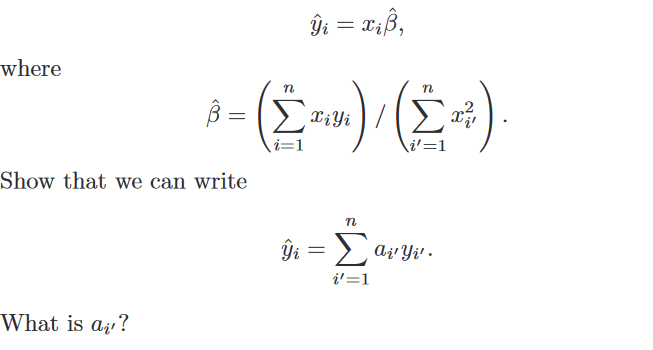

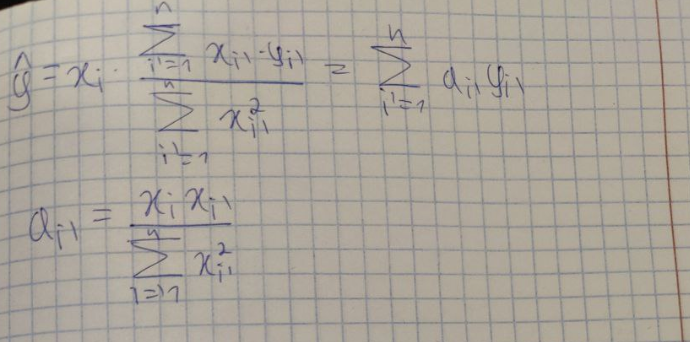